In [63]:
import pandas as pd
import numpy as np

# 先讀進模擬資料
# data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\embedding_data.csv")

data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\B\raw_data.csv")

cols = data.columns[:-1].to_list() 

whole = data.copy()

data = whole.iloc[0:35,:]

# data[cols] = (data[cols] - data[cols].mean()) / data[cols].std() # 針對變數標準化，後面做softmax的時候，數值才不會爆掉

validation = whole.iloc[35:50,:]

# validation[cols] = (validation[cols] - validation[cols].mean()) / validation[cols].std()

# print(len(whole))
# print(len(data))
# print(len(validation))
print(data)

          X1        X2        X3        X4        X5        X6        X7  \
0   0.496714  0.458888 -0.138264 -0.163134  0.647689  0.657016  1.523030   
1  -0.234137 -0.206601  1.579213  1.562407  0.767435  0.811695 -0.469474   
2  -0.463418 -0.399753 -0.465730 -0.443311  0.241962  0.267692 -1.913280   
3  -0.562288 -0.531314 -1.012831 -0.994520  0.314247  0.309449 -0.908024   
4   1.465649  1.420068 -0.225776 -0.226403  0.067528  0.066958 -1.424748   
5   0.110923  0.096396 -1.150994 -1.147474  0.375698  0.345622 -0.600639   
6  -0.601707 -0.563699  1.852278  1.890608 -0.013497 -0.014053 -1.057711   
7  -1.220844 -1.242074  0.208864  0.191116 -1.959670 -1.968330 -1.328186   
8   0.738467  0.751781  0.171368  0.187781 -0.115648 -0.105967 -0.301104   
9  -0.719844 -0.696605 -0.460639 -0.466705  1.057122  1.032305  0.343618   
10  0.324084  0.296276 -0.385082 -0.391613 -0.676922 -0.661342  0.611676   
11  0.931280  0.929494 -0.839218 -0.806254 -0.309212 -0.263230  0.331263   
12 -0.479174

In [64]:
X = data[cols]

XTX = X.T @ X

y = data["Y"]

# beta
beta = np.linalg.inv(X.T @ X) @ X.T @ y

print("手算:")
print(beta)
print("---------------------------------------------")

# 用套件驗證
import statsmodels.api as sm

X = data[cols]

model = sm.OLS(
    data["Y"],
    X          # 不加 constant
)

result = model.fit()

print("套件驗證:")
print(result.params)

手算:
0    1.635490
1    0.237266
2   -1.060083
3    2.988039
4    1.066174
5   -0.933764
6    2.651680
7   -2.423137
8   -3.665030
9    3.820952
dtype: float64
---------------------------------------------
套件驗證:
X1     1.635490
X2     0.237266
X3    -1.060083
X4     2.988039
X5     1.066174
X6    -0.933764
X7     2.651680
X8    -2.423137
X9    -3.665030
X10    3.820952
dtype: float64


In [65]:
import torch

X = torch.tensor(
    data[cols].values,
    dtype=torch.float32
)

y = torch.tensor(
    data["Y"].values,
    dtype=torch.float32
)

# y_true = y.mean()

# y_true = y_true.reshape(1,1)

N = X.shape[0]
P = X.shape[1]

In [66]:
y

tensor([ 1.3969,  4.0829, -2.8144, -2.3084,  1.6315, -2.3027,  1.7992, -2.6008,
         1.7035, -2.8305,  0.0969,  0.1472, -1.4616,  1.5208,  2.9449,  2.2607,
         0.7366, -0.1436,  2.0015, -1.4508, -4.7132,  4.5727, -4.0669,  1.0248,
        -0.9216,  0.5792, -4.0443,  1.4263,  3.0038, -1.5963,  1.6298,  0.6284,
        -0.3550,  1.1283, -3.5593])

In [67]:
X

tensor([[ 0.4967,  0.4589, -0.1383, -0.1631,  0.6477,  0.6570,  1.5230,  1.4752,
         -0.2342, -0.2360],
        [-0.2341, -0.2066,  1.5792,  1.5624,  0.7674,  0.8117, -0.4695, -0.4875,
          0.5426,  0.5712],
        [-0.4634, -0.3998, -0.4657, -0.4433,  0.2420,  0.2677, -1.9133, -1.9131,
         -1.7249, -1.7545],
        [-0.5623, -0.5313, -1.0128, -0.9945,  0.3142,  0.3094, -0.9080, -0.9066,
         -1.4123, -1.3972],
        [ 1.4656,  1.4201, -0.2258, -0.2264,  0.0675,  0.0670, -1.4247, -1.4383,
         -0.5444, -0.5603],
        [ 0.1109,  0.0964, -1.1510, -1.1475,  0.3757,  0.3456, -0.6006, -0.5820,
         -0.2917, -0.3155],
        [-0.6017, -0.5637,  1.8523,  1.8906, -0.0135, -0.0141, -1.0577, -1.0897,
          0.8225,  0.8193],
        [-1.2208, -1.2421,  0.2089,  0.1911, -1.9597, -1.9683, -1.3282, -1.3325,
          0.1969,  0.1658],
        [ 0.7385,  0.7518,  0.1714,  0.1878, -0.1156, -0.1060, -0.3011, -0.2975,
         -1.4785, -1.4951],
        [-0.7198, -

In [68]:
import torch.nn as nn

embedding_dim = len(data)
dk = 4

wq = torch.randn(
    dk,
    embedding_dim,
    requires_grad=True
)

wk = torch.randn(
    dk,
    embedding_dim,
    requires_grad=True
)

# 先不需要V
# wv = torch.randn(
#     embedding_dim,
#     embedding_dim,
#     requires_grad=True
# )

# proj = nn.Linear(
#     embedding_dim,
#     1
# )

# linear = nn.Linear(
#     P,
#     1
# )

In [69]:
optimizer = torch.optim.Adam(

    [wq,wk], # wv

    # +list(proj.parameters())

    # +list(linear.parameters()),

    lr=0.001

)

In [70]:
import numpy as np
import torch.nn.functional as F

lam = 1

p = X.shape[1]

I = torch.eye(
    p,
    dtype=X.dtype,
    device=X.device
)

loss_history = []

initial_attn = None

epochs = 1000

for epoch in range(epochs):

    E = X

    Q = wq @ E

    K = wk @ E

    scores = K.T @ Q 

    scores = scores / np.sqrt(dk)

    attn = F.softmax(
        scores,
        dim=0
    )

    A = attn @ attn.T + lam * I

    # beta
    beta = torch.linalg.solve(
    X.T @ X + A,
    X.T @ y
    )

    # V = wv @ E

    # delta_E = V @ attn

    # New_E = E + delta_E

    # z = proj(
    # New_E.T
    # )

    # z = z.reshape(1,-1)

    # y_hat = linear(z)

#    mse_loss = F.mse_loss(
#    y_hat,
#    y
#    )

#    lambda_attn=0.1

#    loss = (
#        mse_loss
#        +
#        lambda_attn *
#        torch.mean(attn**2)
#    )

    y_hat = X @ beta

    loss = F.mse_loss(
    y_hat,
    y
    )


    if epoch == 0:
        initial_attn = attn.detach().clone()

        # mean_initial_attn = initial_attn.mean(dim=0)

        # print(E.shape)

        # print(Q.shape)

        # print(K.shape)

        # print(scores.shape)

        # print(attn.shape)

        # print(V.shape)

        # print(delta_E.shape)

        # print(New_E.shape)

        # print(z.shape)

        print(y_hat.shape)
        
        print(y.shape)


    loss_history.append(
        loss.item()
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

# =====================
# 訓練完成後重新 forward
# 取得最後 attention
# =====================

with torch.no_grad():

    E = X

    Q = wq @ E

    K = wk @ E

    scores = K.T @ Q 

    scores = scores / np.sqrt(dk)

    attn = F.softmax(
        scores,
        dim=0
    )

    final_attn = attn.clone()
    
    A = attn @ attn.T + lam * I

    # beta
    beta1 = torch.linalg.solve(
    X.T @ X + A,
    X.T @ y
    )

print("訓練完之後的beta:")
print(beta1)

# =====================
# Average attention matrix across all samples
# =====================

# mean_attn = final_attn.mean(dim=0)



torch.Size([35])
torch.Size([35])
訓練完之後的beta:
tensor([ 0.9577,  0.9125,  0.8396,  1.0473,  0.0132,  0.0699,  0.2097,  0.0139,
        -0.1259,  0.3032])


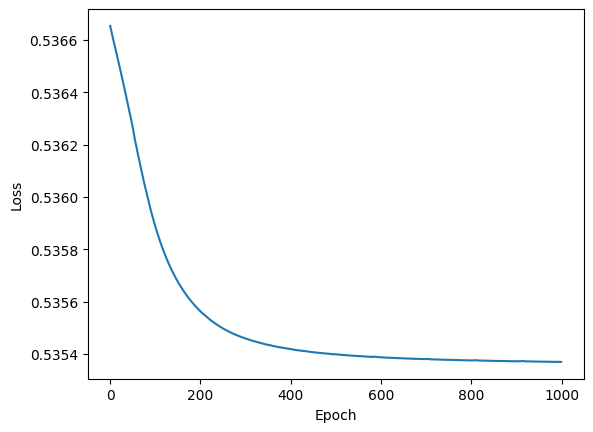

In [71]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

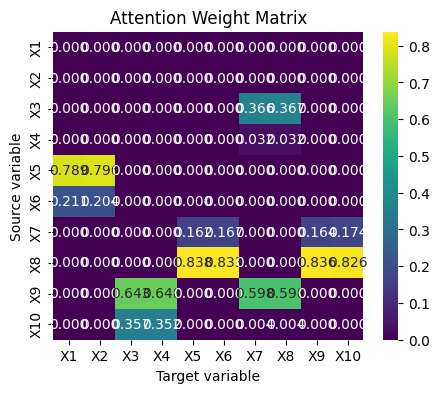

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
# 轉成 numpy
attn_matrix = final_attn.detach().numpy()

# 設定變數名稱
labels = cols

plt.figure(figsize=(5,4))

sns.heatmap(
    attn_matrix,
    annot=True,        # 顯示數值
    fmt=".3f",         # 小數三位
    xticklabels=labels,
    yticklabels=labels,
    cmap="viridis"
)

plt.xlabel("Target variable")
plt.ylabel("Source variable")
plt.title("Attention Weight Matrix")

plt.show()

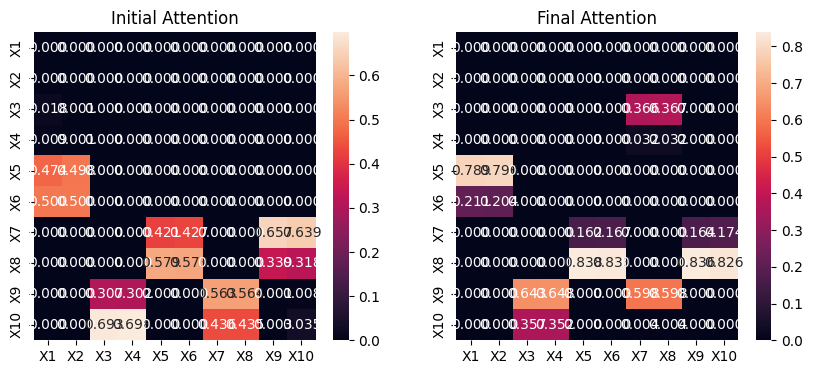

In [73]:
fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.heatmap(
    initial_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_title("Initial Attention")


sns.heatmap(
    final_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_title("Final Attention")


plt.show()

In [74]:
beta_ols = result.params.values
beta_attn = beta1.detach().numpy()

In [75]:
print(beta_ols)
print(beta_attn)

[ 1.63549031  0.23726604 -1.06008322  2.9880393   1.06617358 -0.93376385
  2.65168016 -2.42313748 -3.66503039  3.82095184]
[ 0.9577096   0.9125221   0.8396203   1.0472766   0.01324419  0.06993837
  0.20967019  0.01391454 -0.12594263  0.30322906]


In [76]:
X_val = validation[cols].values
y_val = validation["Y"].values

y_pred_ols = X_val @ beta_ols

y_pred_attn = X_val @ beta_attn

In [77]:
from sklearn.metrics import mean_squared_error

mse_ols = mean_squared_error(
    y_val,
    y_pred_ols
)

mse_attn = mean_squared_error(
    y_val,
    y_pred_attn
)

print(f"OLS MSE = {mse_ols:.6f}")
print(f"Attention MSE = {mse_attn:.6f}")

OLS MSE = 0.844377
Attention MSE = 0.798796


In [78]:
rmse_ols = np.sqrt(mse_ols)
rmse_attn = np.sqrt(mse_attn)

print(f"OLS MSE = {rmse_ols:.6f}")
print(f"Attention MSE = {rmse_attn:.6f}")

OLS MSE = 0.918900
Attention MSE = 0.893754


In [79]:
from sklearn.metrics import r2_score

ols_r2 = r2_score(y_val, y_pred_ols)
attn_r2 = r2_score(y_val, y_pred_attn)

print(f"OLS R² = {ols_r2:.6f}")
print(f"Attention R² = {attn_r2:.6f}")

OLS R² = 0.750640
Attention R² = 0.764101


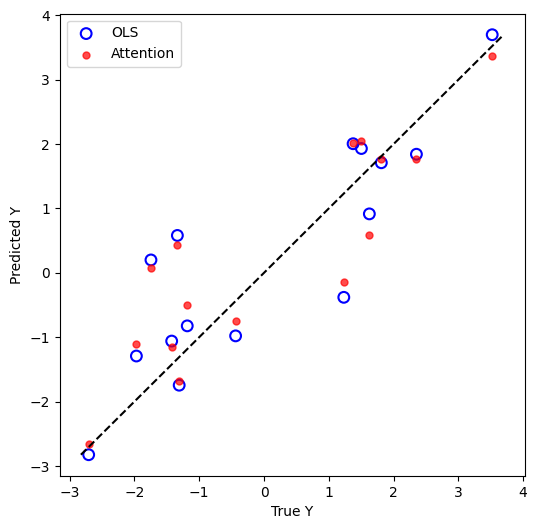

In [80]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_val,
    y_pred_ols,
    facecolors="none",
    edgecolors="blue",
    s=60,
    linewidth=1.5,
    label="OLS"
)

plt.scatter(
    y_val,
    y_pred_attn,
    color="red",
    s=25,
    alpha=0.7,
    label="Attention"
)

low = min(y_val.min(), y_pred_ols.min(), y_pred_attn.min())
high = max(y_val.max(), y_pred_ols.max(), y_pred_attn.max())

plt.plot([low, high], [low, high], "k--")

plt.xlabel("True Y")
plt.ylabel("Predicted Y")
plt.legend()
plt.show()

In [83]:
true_beta = pd.read_csv(
    r"C:\Users\USER\Desktop\碩論\程式碼\B\true_beta.csv"
)

beta_true = true_beta["True_beta"].values

print(beta_true)

[1.  0.8 1.  0.8 0.  0.  0.  0.  0.  0. ]


In [88]:
ols_bias = abs(beta_ols - beta_true)
attn_bias = abs(beta_attn - beta_true)

print(ols_bias.sum())
print(attn_bias.sum())

20.007084096497522
1.298407763801515
